In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
import muram as mio


In [2]:
plt.rc('text', usetex = False)

In [ ]:
atm = frz.read_model('/dat/xenosh/muram_plage_pore/26000/muram_026000_nx1536_ny1536_nz240_d605.bin')

In [3]:
syn = frz.read_profile('/dat/xenosh/muram_plage_pore/26000/stokes.bin')

In [4]:
ll = syn.wave/1000+6301.5

In [5]:
muramdir = '/dat/milic/MURaM_400G_plage_pore/3D/'

In [6]:
iter = 26000

In [4]:
Bz = mio.MuramCube(muramdir, iter, 'Bx')
Bz = Bz.transpose(1,2,0)
Bz = Bz[:,:,750:850]
Bz = Bz * np.sqrt(4 * np.pi)

In [6]:
slicez = np.memmap(muramdir[:-3]+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_1.000_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(650,1536,1536))

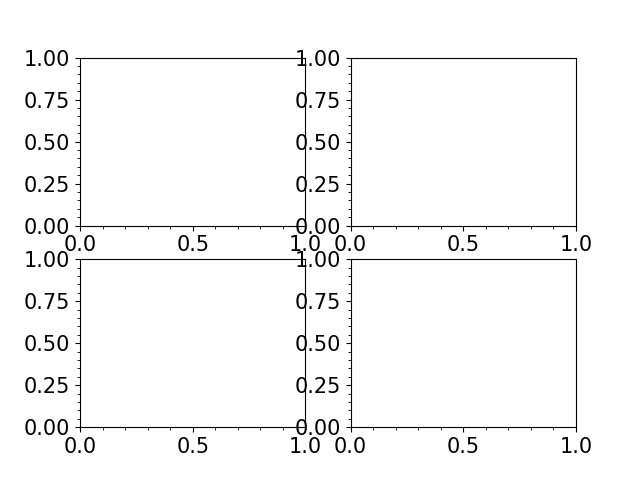

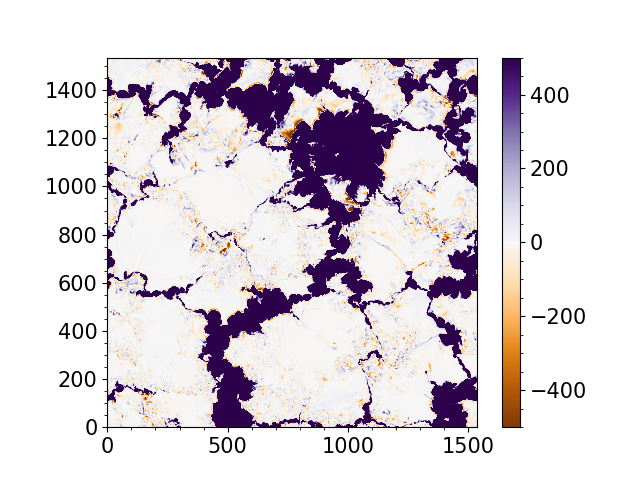

In [8]:
# Create main figure
fig, ax = plt.subplots()
im=ax.imshow(slicez[280,:,:].T*np.sqrt(4*np.pi), cmap="PuOr", origin="lower",vmin=-500,vmax=500)
#im=ax.imshow(Bz[:,:,40].T,cmap="PuOr", origin="lower",vmin=-500,vmax=500)
fig.colorbar(im,ax=ax)
#ax.set_title("")

# Create a second figure for detail plot (initially empty)
fig_detail, ax_detail = plt.subplots(2,2)
#ax_detail.set_title("Click to see details")

def onclick(event):
    if event.inaxes is not None:
        ix, iy = int(event.xdata), int(event.ydata)
        #print(f"Clicked at x={ix}, y={iy}")

        # Clear and redraw the detail figure
        for a in ax_detail.flatten():
            a.clear()
        ax_detail[0,0].plot(ll, syn.stki[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
        ax_detail[0,0].axvline(6301.5,ls='--')
        ax_detail[0,0].axvline(6302.5,ls='--')
        ax_detail[0,1].plot(ll, syn.stkq[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
        ax_detail[1,0].plot(ll, syn.stku[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
        ax_detail[1,1].plot(ll, syn.stkv[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
        fig_detail.suptitle(f"Stokes profiles at ({ix}, {iy})")
        #ax_detail.set_title(f"Stokes profiles at ({ix}, {iy})")
        #ax_detail.legend()

        # Refresh the figure
        fig_detail.canvas.draw()

# Connect click event
cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()